# Test Notebook: Local File Server & Caching

This notebook tests the local HTTP server and caching functionality of IPyPlot.

When you `import ipyplot`, a lightweight HTTP server starts and serves files from `~/.ipyplot/`.
- Local file paths are copied into that folder (preserving their path structure)
- In-memory images are cached by content hash
- Plots use HTTP URLs instead of large base64 payloads

## Test Assets
```
assets/
├── cats/
│   ├── 1.jpg, 2.jpg, 3.jpg, 4.jpg
├── dogs/
│   ├── 1.jpg, 2.jpg, 3.jpg
└── nature/
    ├── 1.jpg, 2.jpg, 3.jpg, 4.jpg, 5.jpg
```

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.insert(0, '../')
import ipyplot

## 1. Server Configuration

Check the default server URL and configure if needed.

In [3]:
# Check the default server URL
print("Server URL:", ipyplot.get_server_url())

Server URL: http://127.0.0.1:39876


In [4]:
# Configure server (optional - for remote notebooks)
# ipyplot.set_server_host("0.0.0.0")  # Bind to all interfaces
# ipyplot.set_server_port(41000)       # Use specific port
# print("Configured server URL:", ipyplot.get_server_url())

## 2. Load Local Image Files

Load images from the `assets/` directory using relative paths.

In [5]:
import glob

# Get the assets directory (relative to notebook)
assets_dir = '../assets'

# Load image paths
cats = sorted(glob.glob(f'{assets_dir}/cats/*.jpg'))
dogs = sorted(glob.glob(f'{assets_dir}/dogs/*.jpg'))
nature = sorted(glob.glob(f'{assets_dir}/nature/*.jpg'))

print(f"Cats: {len(cats)} images")
print(f"  {cats}")
print(f"Dogs: {len(dogs)} images")
print(f"  {dogs}")
print(f"Nature: {len(nature)} images")
print(f"  {nature}")

Cats: 4 images
  ['../assets/cats/1.jpg', '../assets/cats/2.jpg', '../assets/cats/3.jpg', '../assets/cats/4.jpg']
Dogs: 3 images
  ['../assets/dogs/1.jpg', '../assets/dogs/2.jpg', '../assets/dogs/3.jpg']
Nature: 5 images
  ['../assets/nature/1.jpg', '../assets/nature/2.jpg', '../assets/nature/3.jpg', '../assets/nature/4.jpg', '../assets/nature/5.jpg']


## 3. Test: Basic Local File Display

Display local images - the server should cache these files and serve them via HTTP.

In [6]:
# Display all cats using local file paths
print("Displaying cats from local files...")
print("Note: URLs shown should be http://localhost:XXXX/... (served from cache)")
ipyplot.plot_images(cats, img_width=150)

Displaying cats from local files...
Note: URLs shown should be http://localhost:XXXX/... (served from cache)


In [7]:
# Display all local images
all_local_images = cats + dogs + nature
all_labels = ['cat'] * len(cats) + ['dog'] * len(dogs) + ['nature'] * len(nature)

print(f"Displaying {len(all_local_images)} local images...")
ipyplot.plot_images(all_local_images, labels=all_labels, img_width=120)

Displaying 12 local images...


## 4. Test: Dict Input with Local Files

In [8]:
# Dictionary of local images - creates tabs
images_dict = {
    "Cats": cats,
    "Dogs": dogs,
    "Nature": nature
}

print("Testing dict input with local files (tabs)...")
ipyplot.plot_images(images_dict, img_width=150)

Testing dict input with local files (tabs)...


## 5. Test: Grid Layout with Local Files

In [9]:
# Grid mode with local files
images_nested = [cats, dogs, nature]

print("Testing grid layout with local files...")
ipyplot.plot_images(
    images_nested,
    labels=["Cats", "Dogs", "Nature"],
    img_width=150,
    nested_layout='grid'
)

Testing grid layout with local files...


## 6. Test: Tuple Inputs with Local Files

Use `(image_path, label)` tuples for custom labels without showing URLs.

In [10]:
# Tuples with custom labels - URLs should NOT be shown
images_with_labels = [
    (cats[0], "Whiskers"),
    (cats[1], "Mittens"),
    (dogs[0], "Buddy"),
    (dogs[1], "Max"),
    (nature[0], "Mountain"),
    (nature[1], "Forest"),
]

print("Testing tuple (path, label) inputs...")
print("Note: URLs should NOT be shown, only custom labels")
ipyplot.plot_images(images_with_labels, img_width=150)

Testing tuple (path, label) inputs...
Note: URLs should NOT be shown, only custom labels


In [11]:
# Grid with tuple labels
grid_with_labels = [
    [(cats[0], "Cat 1"), (cats[1], "Cat 2"), (cats[2], "Cat 3"), (cats[3], "Cat 4")],
    [(dogs[0], "Dog 1"), (dogs[1], "Dog 2"), (dogs[2], "Dog 3")],
    [(nature[0], "View 1"), (nature[1], "View 2"), (nature[2], "View 3"), (nature[3], "View 4"), (nature[4], "View 5")],
]

print("Testing grid with tuple labels...")
ipyplot.plot_images(
    grid_with_labels,
    labels=["Cats", "Dogs", "Nature"],
    img_width=120,
    nested_layout='grid'
)

Testing grid with tuple labels...


## 7. Test: PIL Images (In-Memory Caching)

When using PIL.Image objects, images are cached by content hash.

In [12]:
from PIL import Image

# Load images as PIL objects
cats_pil = [Image.open(img) for img in cats]
dogs_pil = [Image.open(img) for img in dogs]

print(f"Loaded {len(cats_pil)} cat images as PIL.Image objects")
print(f"Loaded {len(dogs_pil)} dog images as PIL.Image objects")

Loaded 4 cat images as PIL.Image objects
Loaded 3 dog images as PIL.Image objects


In [13]:
# Display PIL images - should be cached by content hash
print("Displaying PIL images (cached by content hash)...")
ipyplot.plot_images(cats_pil + dogs_pil, img_width=150)

Displaying PIL images (cached by content hash)...


In [14]:
# PIL images with tuple labels
pil_with_labels = [
    (cats_pil[0], "PIL Cat 1"),
    (cats_pil[1], "PIL Cat 2"),
    (dogs_pil[0], "PIL Dog 1"),
    (dogs_pil[1], "PIL Dog 2"),
]

print("Testing PIL images with tuple labels...")
ipyplot.plot_images(pil_with_labels, img_width=150)

Testing PIL images with tuple labels...


## 8. Test: NumPy Arrays (In-Memory Caching)

In [15]:
import numpy as np

# Convert PIL images to numpy arrays
cats_np = [np.array(img) for img in cats_pil]
dogs_np = [np.array(img) for img in dogs_pil]

print(f"Loaded {len(cats_np)} cat images as numpy arrays")
print(f"Shape of first cat image: {cats_np[0].shape}")

Loaded 4 cat images as numpy arrays
Shape of first cat image: (200, 200, 3)


In [16]:
# Display numpy arrays - should be cached by content hash
print("Displaying numpy arrays (cached by content hash)...")
ipyplot.plot_images(cats_np + dogs_np, img_width=150)

Displaying numpy arrays (cached by content hash)...


In [17]:
# Numpy arrays with tuple labels in dict
np_dict = {
    "Cats (numpy)": [(cats_np[i], f"NP Cat {i+1}") for i in range(len(cats_np))],
    "Dogs (numpy)": [(dogs_np[i], f"NP Dog {i+1}") for i in range(len(dogs_np))],
}

print("Testing numpy arrays with tuple labels in dict...")
ipyplot.plot_images(np_dict, img_width=150)

Testing numpy arrays with tuple labels in dict...


## 9. Test: plot_class_tabs with Local Files

In [18]:
# Use plot_class_tabs with local files
all_images = cats + dogs + nature
all_labels = ['cats'] * len(cats) + ['dogs'] * len(dogs) + ['nature'] * len(nature)

print("Testing plot_class_tabs with local files...")
ipyplot.plot_class_tabs(all_images, all_labels, img_width=150)

Testing plot_class_tabs with local files...


## 10. Test: plot_class_representations with Local Files

In [19]:
# Use plot_class_representations with local files
print("Testing plot_class_representations with local files...")
ipyplot.plot_class_representations(all_images, all_labels, img_width=150)

Testing plot_class_representations with local files...


## 11. Test: Force Base64 Mode

With `force_b64=True`, images are converted to base64 instead of using the HTTP server.

Testing force_b64=True (base64 encoded, no HTTP server)...



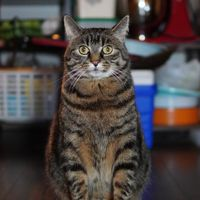
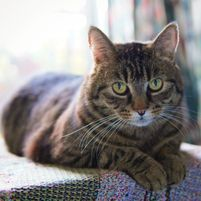


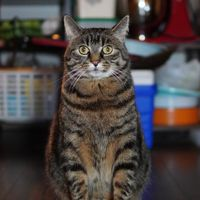
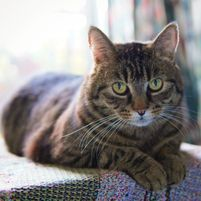

In [20]:
# Force base64 conversion (bypasses HTTP server cache)
print("Testing force_b64=True (base64 encoded, no HTTP server)...")
ipyplot.plot_images(cats[:2], img_width=150, force_b64=True)

## 12. Verify Cache Directory

Check the cache directory to see cached files.

In [21]:
import os
from pathlib import Path

cache_dir = Path.home() / '.ipyplot'
print(f"Cache directory: {cache_dir}")
print(f"Cache directory exists: {cache_dir.exists()}")

if cache_dir.exists():
    # Count files in cache
    cache_files = list(cache_dir.rglob('*'))
    file_count = sum(1 for f in cache_files if f.is_file())
    print(f"Total cached files: {file_count}")
    
    # Show some cached files
    print("\nSample cached files:")
    for f in list(cache_files)[:10]:
        if f.is_file():
            print(f"  {f.relative_to(cache_dir)}")

Cache directory: /Users/shnam48/.ipyplot
Cache directory exists: True
Total cached files: 19

Sample cached files:
  generated/166a1f8ccf3c506326caba30220b69c41ed4ed880e512880ed3adeff6e291177.png
  generated/3a63548e0cd6c541266be6062bb2fcff49744ccee6c6a35966417e2776ec8df6.png
  generated/9c8d478d007e8a2889ccb12e98d2b73f5a0b58e420a830eef2362c0f6e62aedb.png
  generated/5f30ca22a17d2097544459eb7b6f66e483495cc9cc49fcdd9470ded5dc14fa84.png
  generated/86069382812dd75f2c226101c7efc62fafcfc5569e4d0bd2ee6631e37861ff66.png
  generated/2ddf5e19b804ac49e6261a1207c7e6851bb31227f9a819cc800dd84971dfc905.png
  generated/fa5f4fbd3802afe7037ce4001ca4eb59dbb10a58d9ff87fd721a5afa20b23c43.png


## Summary

This notebook tested the local HTTP server and caching functionality:

1. **Server configuration** - `get_server_url()`, `set_server_host()`, `set_server_port()`
2. **Local file caching** - Local file paths are served via HTTP from `~/.ipyplot/`
3. **In-memory image caching** - PIL.Image and numpy arrays are cached by content hash
4. **All input formats work** - flat lists, dicts, nested lists, tuples
5. **All layout modes work** - default grid, tabs, fixed grid
6. **All plotting functions work** - `plot_images`, `plot_class_tabs`, `plot_class_representations`
7. **force_b64 option** - Bypasses HTTP server, uses base64 encoding directly